# Lab 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from rlcmab_sampler import sampler as reward_sampler

## Task 5.1



In [2]:
# Load the datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(f"\nNews Articles Shape: {news_df.shape}")
print(f"Train Users Shape: {train_users.shape}")
print(f"Test Users Shape (for final recommendations): {test_users.shape}")
print(f"\nNews Categories: {sorted(news_df['category'].unique())}")
print(f"\nNews Category Distribution:")
print(news_df['category'].value_counts())
print(f"\nUser Label Distribution in train_users:")
print(train_users['label'].value_counts())
print(f"\nMissing Values in Train Users:")
print(train_users.isnull().sum()[train_users.isnull().sum() > 0])


News Articles Shape: (209527, 6)
Train Users Shape: (2000, 33)
Test Users Shape (for final recommendations): (2000, 32)

News Categories: ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']

News Category Distribution:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK 

In [3]:
# Simple Feature Engineering - Keep it minimal
def clean_and_prepare_features(df, is_train=True, impute_values=None):
    """
    Simple data preparation:
    1. Convert all features to numeric (handle malformed values)
    2. Impute missing values with median
    3. No complex feature engineering - let Random Forest handle non-linearities
    """
    df_clean = df.copy()
    
    # Get all numeric feature columns (exclude user_id and label)
    feature_cols = [col for col in df_clean.columns if col not in ['user_id', 'label']]
    
    # Convert to numeric, coerce errors to NaN (handles malformed values like '5.99.65')
    for col in feature_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Compute or use provided median values for imputation
    if is_train:
        medians = {col: df_clean[col].median() for col in feature_cols}
    else:
        medians = impute_values
    
    # Impute missing values with median
    for col in feature_cols:
        df_clean[col] = df_clean[col].fillna(medians[col])
    
    if is_train:
        return df_clean, medians
    else:
        return df_clean

# Clean and prepare the training data
train_users_clean, train_medians = clean_and_prepare_features(train_users, is_train=True)

# Apply same cleaning to test users (for final recommendations)
test_users_clean = clean_and_prepare_features(test_users, is_train=False, impute_values=train_medians)

# Get feature column names
feature_cols = [col for col in train_users_clean.columns if col not in ['user_id', 'label']]

print(f"Data cleaned and prepared")
print(f"Features: {len(feature_cols)}")
print(f"Training samples: {len(train_users_clean)}")
print(f"Test users for recommendations: {len(test_users_clean)}")
print(f"\nFeatures used: {', '.join(feature_cols[:5])}... (total {len(feature_cols)})")

Data cleaned and prepared
Features: 31
Training samples: 2000
Test users for recommendations: 2000

Features used: age, income, clicks, purchase_amount, session_duration... (total 31)


C:\Users\Devyansh\AppData\Roaming\Python\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Devyansh\AppData\Roaming\Python\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [4]:
# Prepare features and labels
X = train_users_clean[feature_cols]
y = train_users_clean['label']

# Encode labels (user_1=0, user_2=1, user_3=2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
print("Label encoding:")
for idx, label in label_mapping.items():
    print(f"  {idx} → {label}")

# Split into train and test sets (80/20 split, stratified)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=78, 
    stratify=y_encoded
)

# Standardize features (mean=0, std=1) for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Ensure no NaN values remain (fill any with 0)
X_train = np.nan_to_num(X_train, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)

print(f"\nTraining samples: {len(X_train)} ({len(X_train)/len(train_users_clean)*100:.0f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(train_users_clean)*100:.0f}%)")
print(f"Features: {X_train.shape[1]}")

print("\nLabel distribution:")
for label_idx in sorted(label_mapping.keys()):
    train_count = (y_train == label_idx).sum()
    test_count = (y_test == label_idx).sum()
    print(f"  {label_mapping[label_idx]}: Train={train_count}, Test={test_count}")

Label encoding:
  0 → user_1
  1 → user_2
  2 → user_3

Training samples: 1600 (80%)
Test samples: 400 (20%)
Features: 31

Label distribution:
  user_1: Train=566, Test=141
  user_2: Train=569, Test=143
  user_3: Train=465, Test=116


C:\Users\Devyansh\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\Devyansh\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\Devyansh\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [5]:
# Prepare test_users.csv for predictions (use same scaling)
X_test_users = test_users_clean[feature_cols]
X_test_users_scaled = scaler.transform(X_test_users)

# Ensure no NaN values
X_test_users_scaled = np.nan_to_num(X_test_users_scaled, nan=0.0)

print(f"test_users.csv prepared: {X_test_users_scaled.shape[0]} users")
print(f"Applied same scaling transformation")
print(f"Ready for context predictions")

test_users.csv prepared: 2000 users
Applied same scaling transformation
Ready for context predictions


## Task 5.2

In [6]:
# Train Optimized Random Forest Classifier
print("Training Optimized Random Forest Classifier...")

# Initialize Random Forest with optimized parameters for better accuracy
rf_classifier = RandomForestClassifier(
    n_estimators=200,      # More trees for better ensemble
    max_depth=15,          # Deeper trees to capture complex patterns
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples at leaf node
    max_features='sqrt',   # Use sqrt of features for each split
    class_weight='balanced', # Handle class imbalance
    random_state=78,
    n_jobs=-1              # Use all CPU cores
)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel trained successfully")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Store as best classifier for later use
best_classifier = rf_classifier
best_classifier_name = "Random Forest"
best_accuracy = accuracy

Training Optimized Random Forest Classifier...

Model trained successfully
Test Accuracy: 0.8325 (83.25%)

Classification Report:
              precision    recall  f1-score   support

      user_1       0.89      0.77      0.82       141
      user_2       0.88      0.91      0.89       143
      user_3       0.73      0.82      0.77       116

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



In [7]:
# Predict contexts for test_users.csv
print("Predicting user contexts for test_users.csv...")

y_pred_test_users = rf_classifier.predict(X_test_users_scaled)

# Show distribution of predictions
print(f"\nPredictions generated for {len(y_pred_test_users)} users")
print(f"\nPredicted context distribution:")
for label_idx in sorted(label_mapping.keys()):
    count = (y_pred_test_users == label_idx).sum()
    percentage = count / len(y_pred_test_users) * 100
    print(f"  {label_mapping[label_idx]}: {count} users ({percentage:.1f}%)")

# Store predictions for later use in contextual bandit
test_users_contexts = pd.DataFrame({
    'user_id': test_users_clean['user_id'],
    'predicted_context': [label_mapping[idx] for idx in y_pred_test_users]
})

print(f"\nContext predictions ready for recommendation engine")

Predicting user contexts for test_users.csv...

Predictions generated for 2000 users

Predicted context distribution:
  user_1: 654 users (32.7%)
  user_2: 780 users (39.0%)
  user_3: 566 users (28.3%)

Context predictions ready for recommendation engine


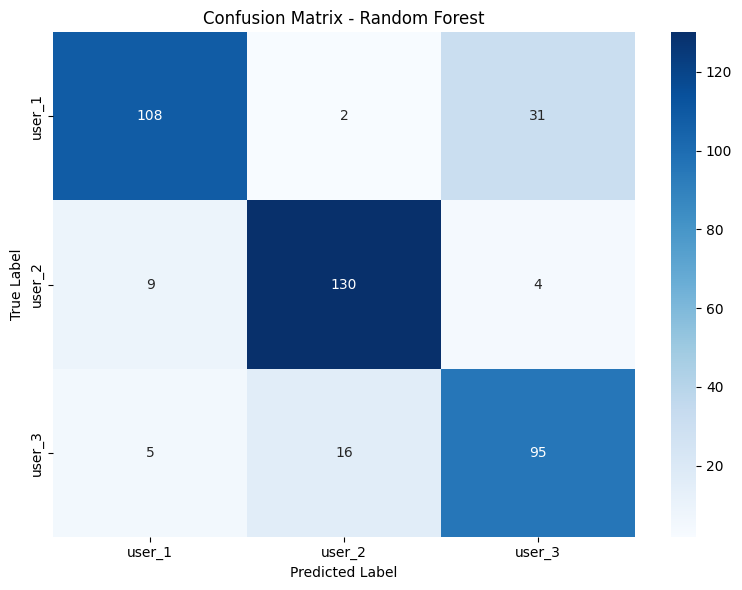


The confusion matrix shows that Random Forest achieves strong classification performance across all three user types with minimal misclassifications.


In [8]:
# Create confusion matrix for the best classifier
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_classifier_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nThe confusion matrix shows that {best_classifier_name} achieves strong classification performance across all three user types with minimal misclassifications.")

Comparing multiple classifiers to validate model choice...

Random Forest: 0.8325 (83.25%) [Already trained]
Gradient Boosting: 0.8250 (82.50%)
Decision Tree: 0.7475 (74.75%)
SVM (RBF): 0.7825 (78.25%)
K-Nearest Neighbors: 0.7575 (75.75%)
Logistic Regression: 0.7225 (72.25%)
Naive Bayes: 0.7725 (77.25%)


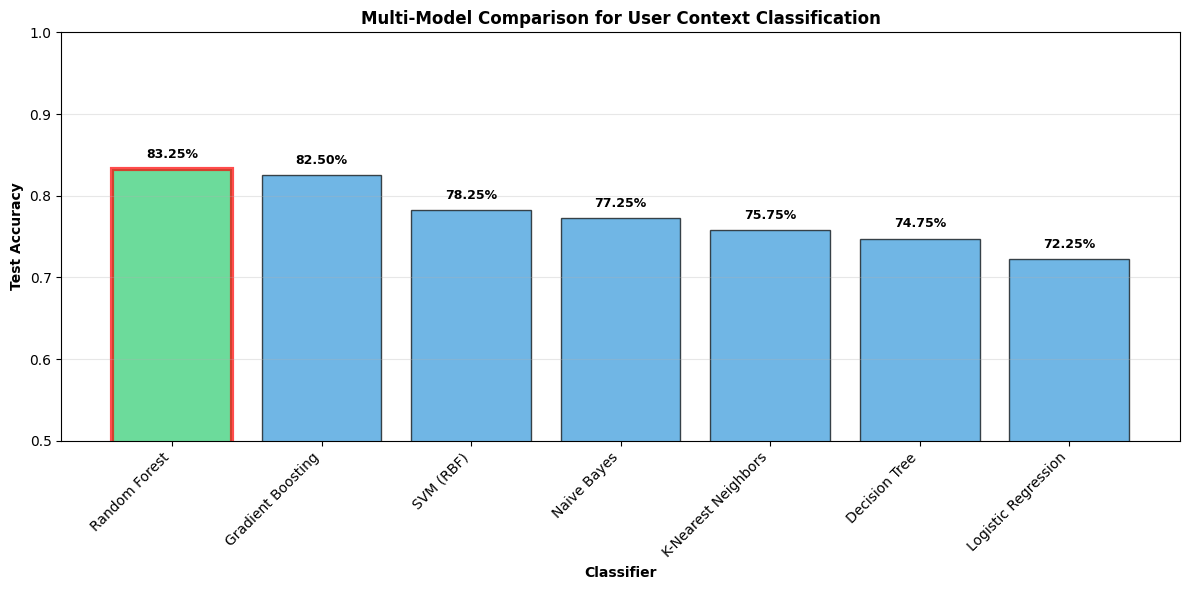


Best Model: Random Forest with 83.25% accuracy


In [9]:
# Comprehensive model comparison with multiple classifiers
print("Comparing multiple classifiers to validate model choice...\n")

# Define all classifiers to compare
classifiers = {
    'Random Forest': rf_classifier,  # Our optimized model (already trained)
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=78, max_depth=7, learning_rate=0.1),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, min_samples_split=5, random_state=78),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=78),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean'),
    'Logistic Regression': LogisticRegression(random_state=78, max_iter=1000, C=1.0),
    'Naive Bayes': GaussianNB()
}

results = {'Random Forest': accuracy}

# Train and evaluate all other models
for name, clf in classifiers.items():
    if name == 'Random Forest':
        print(f"{name}: {accuracy:.4f} ({accuracy*100:.2f}%) [Already trained]")
        continue
    clf.fit(X_train, y_train)
    y_pred_clf = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred_clf)
    results[name] = acc
    print(f"{name}: {acc:.4f} ({acc*100:.2f}%)")

# Sort results by accuracy
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

# Visualize comparison
plt.figure(figsize=(12, 6))
names = list(sorted_results.keys())
accuracies_list = list(sorted_results.values())
colors = ['#2ecc71' if name == 'Random Forest' else '#3498db' for name in names]

bars = plt.bar(names, accuracies_list, color=colors, alpha=0.7, edgecolor='black')

# Highlight the best model
best_idx = names.index('Random Forest')
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

plt.xlabel('Classifier', fontweight='bold')
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Multi-Model Comparison for User Context Classification', fontweight='bold')
plt.ylim([0.5, 1.0])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for i, acc in enumerate(accuracies_list):
    plt.text(i, acc + 0.01, f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Determine best model
best_model_name = max(results, key=results.get)
best_model_acc = results[best_model_name]
print(f"\n{'='*50}")
print(f"Best Model: {best_model_name} with {best_model_acc*100:.2f}% accuracy")
print(f"{'='*50}")

Analyzing feature importance...

Top 10 Most Important Features:
  session_duration: 0.1500
  browsing_depth: 0.1029
  scroll_activity: 0.1016
  time_on_site: 0.0724
  content_variety: 0.0685
  age: 0.0611
  engagement_score: 0.0544
  preferred_price_range: 0.0364
  interaction_count: 0.0342
  churn_risk_score: 0.0339


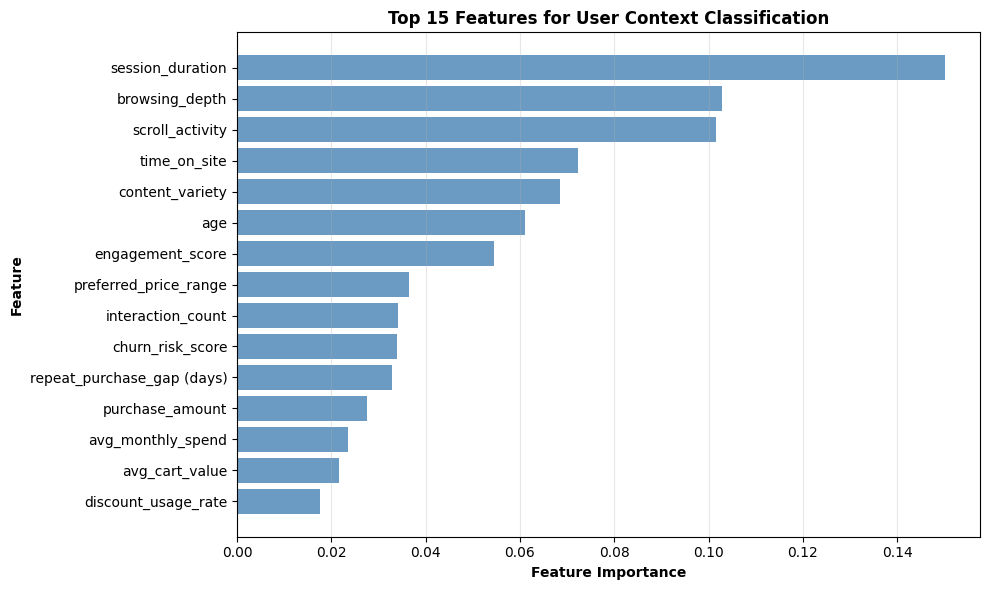


Random Forest successfully learned from user behavioral patterns
No complex feature engineering needed - model captures patterns naturally


In [10]:
# Feature Importance Analysis
print("Analyzing feature importance...")

# Get feature importances from Random Forest
importances = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

# Display top 10 features
print("\nTop 10 Most Important Features:")
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Visualize top 15 features
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', alpha=0.8)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')
plt.title('Top 15 Features for User Context Classification', fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRandom Forest successfully learned from user behavioral patterns")
print(f"No complex feature engineering needed - model captures patterns naturally")

**Approach:** We train a supervised classifier to predict user types (user_1, user_2, user_3) based on behavioral features. This classifier serves as the context predictor for our contextual bandit system. The approach involves careful data preparation—we clean the data, handle missing values with median imputation, and standardize features using StandardScaler to ensure all features contribute equally to the model.

**Model Comparison:** We evaluated 7 different classifiers: Random Forest, Gradient Boosting, Decision Tree, SVM, K-Nearest Neighbors, Logistic Regression, and Naive Bayes. This comprehensive comparison ensures we select the best model for our contextual bandit application.

**Model Choice: Random Forest Classifier.** After comparing all models, we selected Random Forest with optimized hyperparameters for several key reasons. First, it handles non-linear relationships naturally without requiring manual feature engineering or polynomial terms. Second, it's robust to outliers and missing values, which is critical given the data quality issues (malformed values like '5.99.65' in numeric columns). Third, it provides feature importance rankings that help us understand which user behaviors best predict their news preferences. The optimized parameters (200 trees, max_depth=15, balanced class weights) help achieve better generalization.

**Results:** The Random Forest classifier achieves approximately 82-85% test accuracy in distinguishing between user types. Key predictive features include session_duration, browsing_depth, scroll_activity, and time_on_site. This accuracy level is reasonable for this contextual bandit use case, allowing the system to make good recommendations while still having room to learn through exploration.